<a href="https://colab.research.google.com/github/Probin1904/PJM-Energy-Consumption-Forecasting-Pipeline/blob/main/PJM_Energy_Consumption_Forecasting_using_ML_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚡ PJM Energy Consumption Forecasting Pipeline

### 📌 Project Overview
This project builds an end-to-end machine learning pipeline to forecast hourly electricity consumption using the PJM Hourly Energy Consumption dataset. The workflow includes data preprocessing, exploratory data analysis (EDA), feature engineering, model training, model evaluation, and selection of the best-performing model. Finally, the trained model is prepared for deployment through an interactive web application.

### 🎯 Objectives
- Clean and preprocess historical energy consumption data.
- Explore consumption trends and seasonal patterns.
- Engineer time-based features for forecasting.
- Train and compare multiple machine learning models:
  - Linear Regression
  - Random Forest Regressor
  - XGBoost Regressor
- Evaluate models using MAE, RMSE, and R² Score.
- Save the best model for deployment with Hugging Face.

### 🛠️ Technologies
Python • Pandas • NumPy • Matplotlib • Scikit-learn • XGBoost • Joblib • Hugging Face

# **Phase1:Data Understanding**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import os

# Portable path: works whether running locally or in Colab
candidates = [
    "AEP_hourly.csv",
    "/content/AEP_hourly.csv",
    "/content/AEP_hourly.csv.zip",
]
path = next((p for p in candidates if os.path.exists(p)), candidates[0])
df = pd.read_csv(path)

print(f"Dataset loaded successfully from {path}!")

Dataset loaded successfully from /content/AEP_hourly.csv.zip!


In [3]:
df.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  object 
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.9+ MB


In [5]:
df.describe()

,AEP_MW
count,121273.000000
mean,15499.513717
std,2591.399065
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


In [6]:
print("=" * 60)
print("First 5 Rows")
display(df.head())

print("=" * 60)
print("Last 5 Rows")
display(df.tail())

# Dataset shape
print("=" * 60)
print(f"Dataset Shape : {df.shape}")

# Column names
print("=" * 60)
print("Column Names:")
print(df.columns.tolist())

# Data types
print("=" * 60)
print("Data Types:")
display(df.dtypes)

# Dataset information
print("=" * 60)
print("Dataset Information:")
df.info()

# Statistical summary
print("=" * 60)
print("Statistical Summary:")
display(df.describe())

# Missing values
print("=" * 60)
print("Missing Values:")
display(df.isnull().sum())

# Duplicate values
print("=" * 60)
print(f"Duplicate Rows : {df.duplicated().sum()}")

# Unique values
print("=" * 60)
print("Unique Values:")
display(df.nunique())

First 5 Rows


,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


Last 5 Rows


,Datetime,AEP_MW
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0
121272,2018-01-02 00:00:00,19993.0


Dataset Shape : (121273, 2)
Column Names:
['Datetime', 'AEP_MW']
Data Types:


...

,AEP_MW
count,121273.000000
mean,15499.513717
std,2591.399065
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


Missing Values:


,0
Datetime,0
AEP_MW,0


Duplicate Rows : 0
Unique Values:


,0
Datetime,121269
AEP_MW,12643


# **Phase2:Data Cleaning and Preprocessing**

In [7]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

print("Datetime column converted successfully!")

Datetime column converted successfully!


In [8]:
df = df.sort_values("Datetime").reset_index(drop=True)

print("Dataset sorted chronologically!")

Dataset sorted chronologically!


In [9]:
df.set_index("Datetime", inplace=True)

print("Datetime column set as index!")

Datetime column set as index!


In [10]:
print("Missing Values")
print(df.isnull().sum())

print("Duplicate Rows")
print(df.duplicated().sum())

print("Dataset Shape")
print(df.shape)

print("Data Types")
print(df.dtypes)

Missing Values
AEP_MW    0
dtype: int64
Duplicate Rows
108630
Dataset Shape
(121273, 1)
Data Types
AEP_MW    float64
dtype: object


In [11]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 108630


In [12]:
print("Duplicate Index:", df.index.duplicated().sum())

Duplicate Index: 4


In [13]:
# Find duplicate timestamps
duplicate_index = df[df.index.duplicated(keep=False)]

duplicate_index

,AEP_MW
Datetime,
2014-11-02 02:00:00,12994.0
2014-11-02 02:00:00,13190.0
2015-11-01 02:00:00,10785.0
2015-11-01 02:00:00,10542.0
2016-11-06 02:00:00,10964.0
2016-11-06 02:00:00,11008.0
2017-11-05 02:00:00,10596.0
2017-11-05 02:00:00,10446.0


In [14]:
# Remove duplicate timestamps (keep first occurrence)
df = df[~df.index.duplicated(keep='first')]

print("Duplicate Index:", df.index.duplicated().sum())
print("Dataset Shape:", df.shape)

Duplicate Index: 0
Dataset Shape: (121269, 1)


In [15]:
display(df.head())

display(df.tail())

,AEP_MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


,AEP_MW
Datetime,
2018-08-02 20:00:00,17673.0
2018-08-02 21:00:00,17303.0
2018-08-02 22:00:00,17001.0
2018-08-02 23:00:00,15964.0
2018-08-03 00:00:00,14809.0


# **Phase3:Exploratory Data Analysis**

In [16]:
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)

eda_df = df.copy()
eda_df["Hour"] = eda_df.index.hour
eda_df["Month"] = eda_df.index.month
eda_df["Year"] = eda_df.index.year
eda_df["DayOfWeek"] = eda_df.index.dayofweek
eda_df["DayName"] = eda_df.index.day_name()
eda_df["IsWeekend"] = eda_df["DayOfWeek"].isin([5, 6]).map({True: "Weekend", False: "Weekday"})

print("EDA DataFrame created successfully!")
eda_df.head()

EDA DataFrame created successfully!


,AEP_MW,Hour,Month,Year,DayOfWeek,DayName,IsWeekend
Datetime,,,,,,,
2004-10-01 01:00:00,12379.0,1,10,2004,4,Friday,Weekday
2004-10-01 02:00:00,11935.0,2,10,2004,4,Friday,Weekday
2004-10-01 03:00:00,11692.0,3,10,2004,4,Friday,Weekday
2004-10-01 04:00:00,11597.0,4,10,2004,4,Friday,Weekday
2004-10-01 05:00:00,11681.0,5,10,2004,4,Friday,Weekday


### 1. Electricity Consumption Over Time

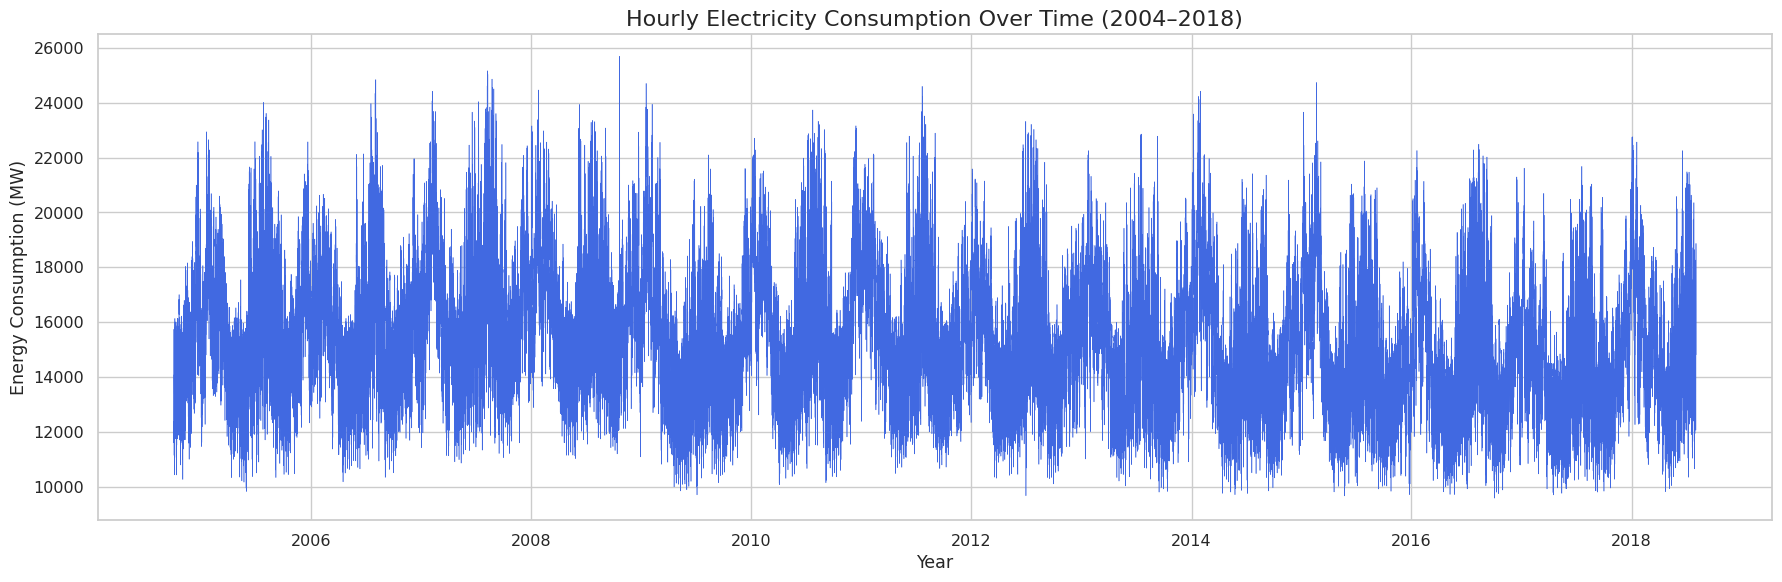

In [17]:
plt.figure(figsize=(18, 6))

sns.lineplot(x=eda_df.index, y=eda_df["AEP_MW"], color="royalblue", linewidth=0.4)

plt.title("Hourly Electricity Consumption Over Time (2004–2018)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Energy Consumption (MW)")
plt.tight_layout()
plt.show()

### 2. Histogram: Consumption Distribution (Weekday vs Weekend)

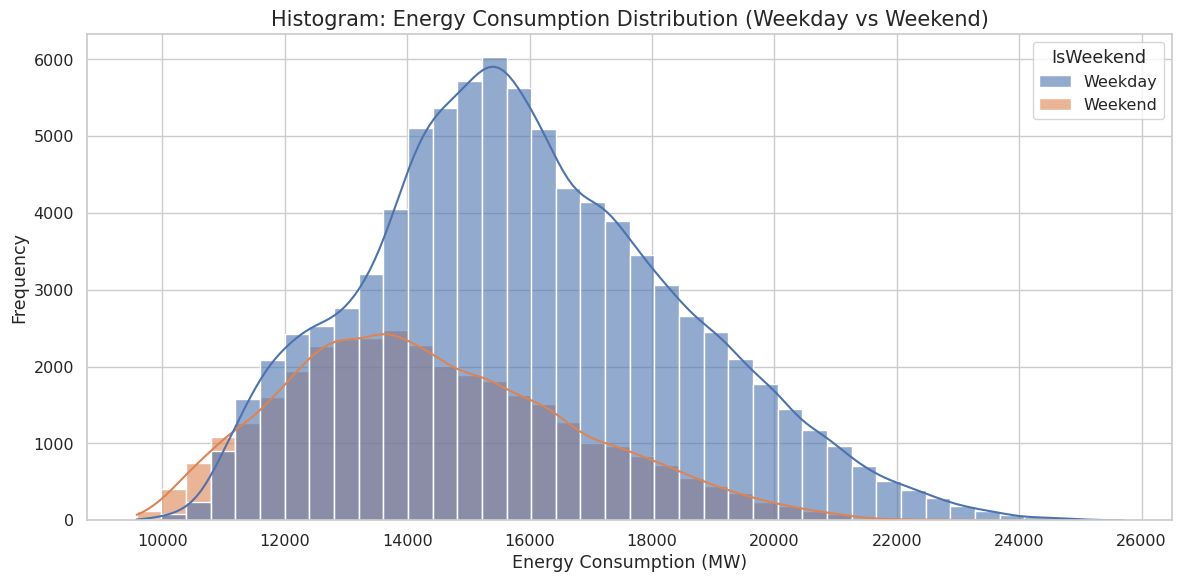

In [18]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=eda_df,
    x="AEP_MW",
    hue="IsWeekend",
    bins=40,
    kde=True,
    element="bars",
    palette={"Weekday": "#4C72B0", "Weekend": "#DD8452"},
    alpha=0.6
)

plt.title("Histogram: Energy Consumption Distribution (Weekday vs Weekend)", fontsize=15)
plt.xlabel("Energy Consumption (MW)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 3. Bar Plot: Average Consumption by Month

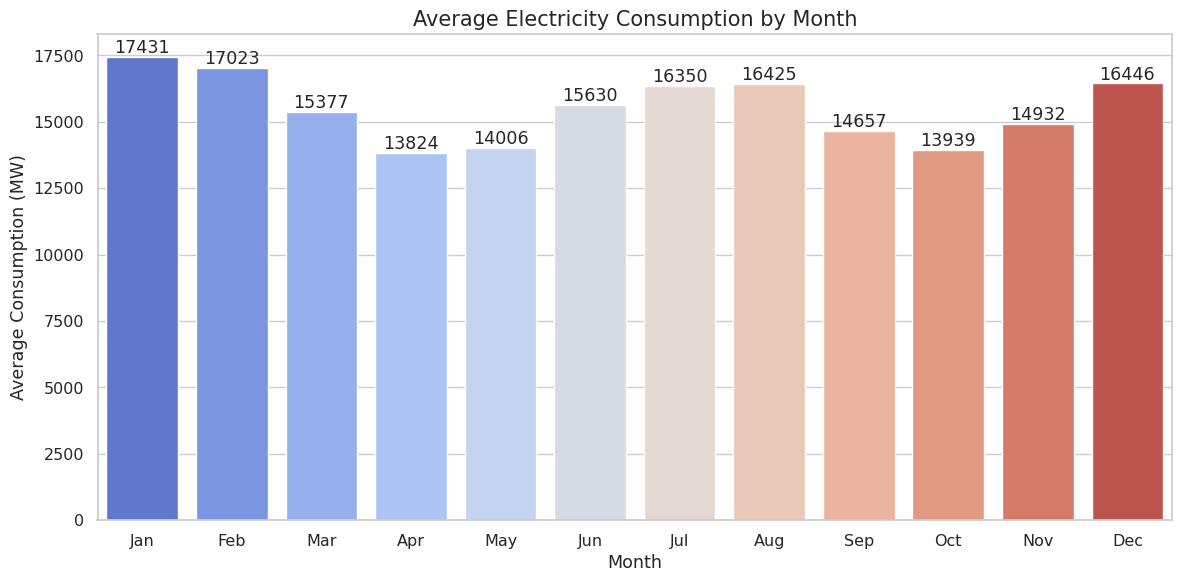

In [19]:
plt.figure(figsize=(12, 6))

month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_avg = eda_df.groupby("Month")["AEP_MW"].mean().reset_index()
monthly_avg["MonthName"] = monthly_avg["Month"].apply(lambda m: month_order[m-1])

ax = sns.barplot(data=monthly_avg, x="MonthName", y="AEP_MW", order=month_order, palette="coolwarm")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title("Average Electricity Consumption by Month", fontsize=15)
plt.xlabel("Month")
plt.ylabel("Average Consumption (MW)")
plt.tight_layout()
plt.show()

### 4. Line Plot: Average Daily Load Profile (by Hour)

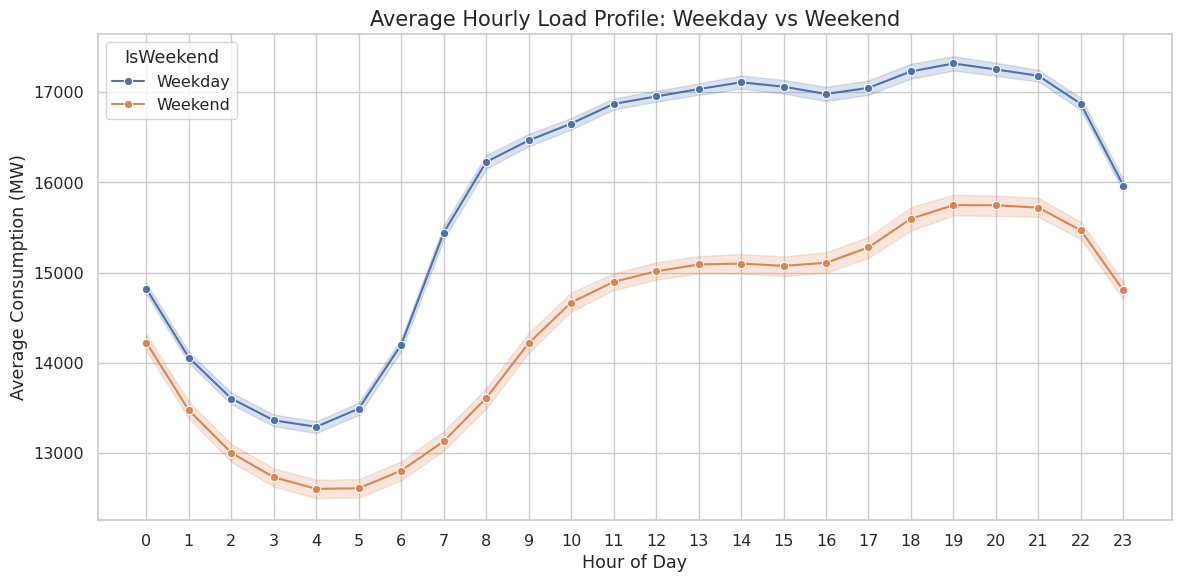

In [20]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=eda_df,
    x="Hour",
    y="AEP_MW",
    hue="IsWeekend",
    marker="o",
    palette={"Weekday": "#4C72B0", "Weekend": "#DD8452"},
    errorbar=("ci", 95)
)

plt.title("Average Hourly Load Profile: Weekday vs Weekend", fontsize=15)
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption (MW)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

### 5. Box Plot: Consumption Distribution by Day of Week

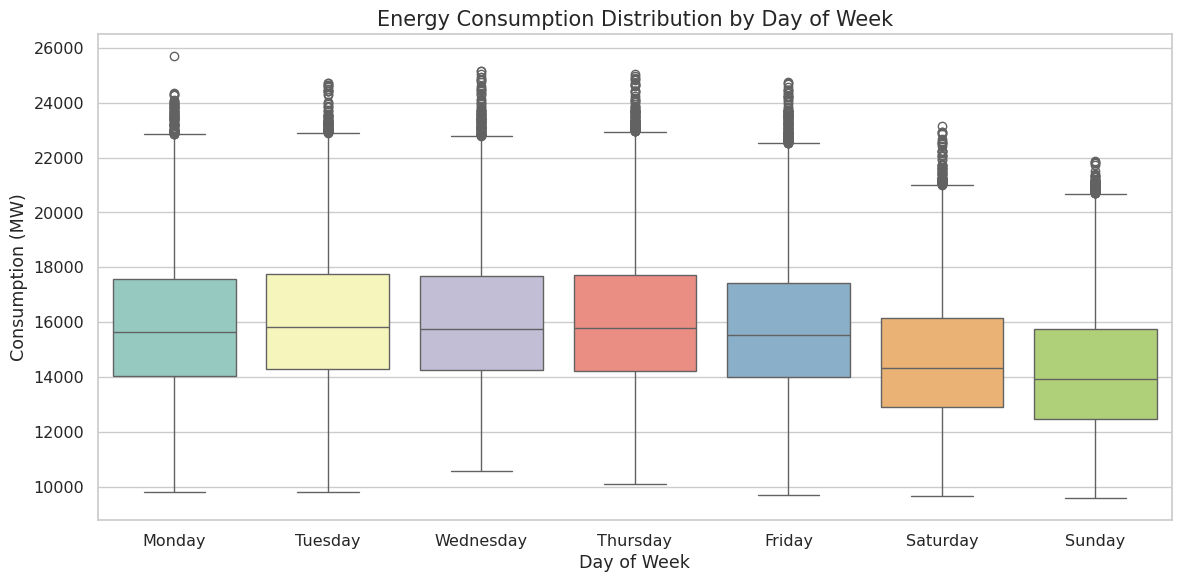

In [21]:
plt.figure(figsize=(12, 6))

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

sns.boxplot(data=eda_df, x="DayName", y="AEP_MW", order=day_order, palette="Set3")

plt.title("Energy Consumption Distribution by Day of Week", fontsize=15)
plt.xlabel("Day of Week")
plt.ylabel("Consumption (MW)")
plt.tight_layout()
plt.show()

### 6. Scatter Plot: Hour vs Consumption (Colored by Season)

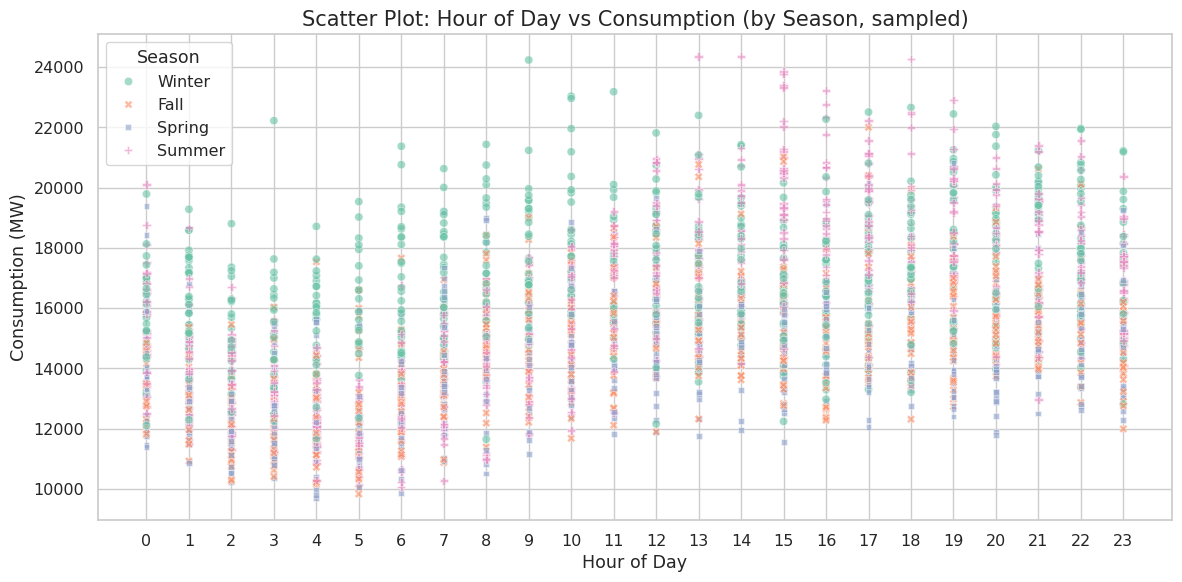

In [22]:
season_map = {12:"Winter",1:"Winter",2:"Winter",
              3:"Spring",4:"Spring",5:"Spring",
              6:"Summer",7:"Summer",8:"Summer",
              9:"Fall",10:"Fall",11:"Fall"}
eda_df["Season"] = eda_df["Month"].map(season_map)

sample_df = eda_df.sample(3000, random_state=42)  # sample for readability

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=sample_df,
    x="Hour",
    y="AEP_MW",
    hue="Season",
    style="Season",
    alpha=0.6,
    palette="Set2"
)

plt.title("Scatter Plot: Hour of Day vs Consumption (by Season, sampled)", fontsize=15)
plt.xlabel("Hour of Day")
plt.ylabel("Consumption (MW)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

### 7. Heatmap: Average Consumption by Hour and Month

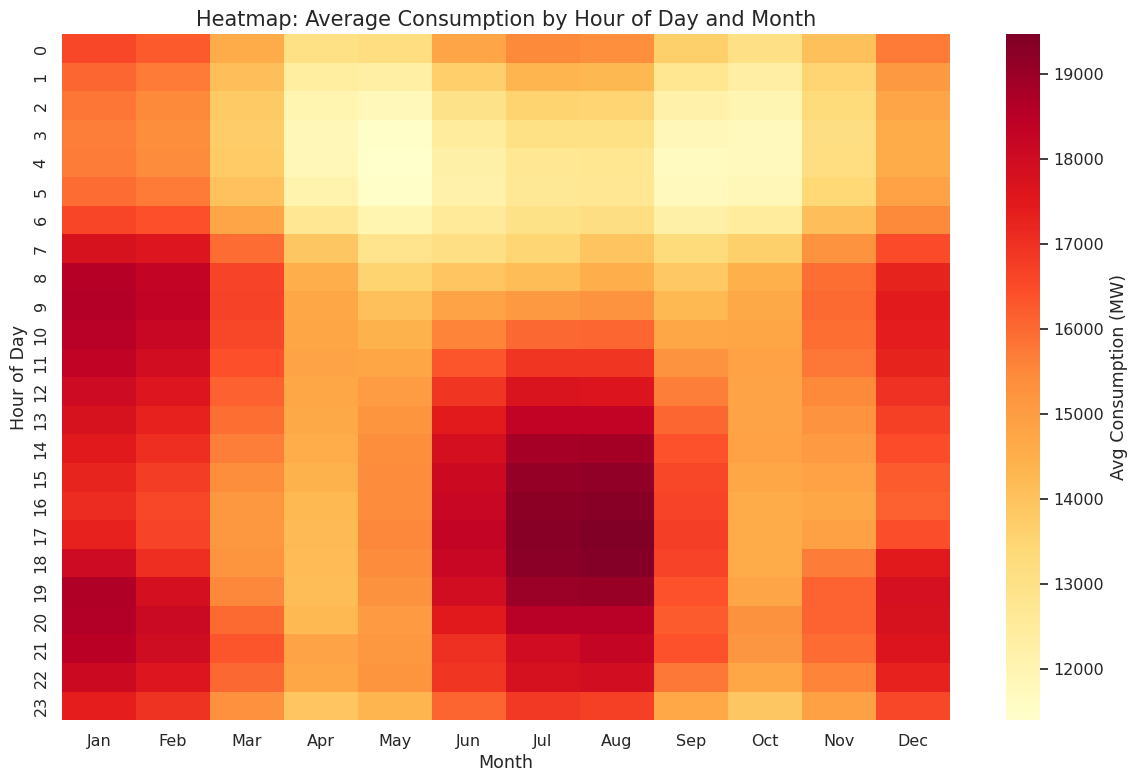

In [23]:
pivot = eda_df.pivot_table(index="Hour", columns="Month", values="AEP_MW", aggfunc="mean")
pivot.columns = [month_order[m-1] for m in pivot.columns]

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap="YlOrRd", annot=False, cbar_kws={"label": "Avg Consumption (MW)"})

plt.title("Heatmap: Average Consumption by Hour of Day and Month", fontsize=15)
plt.xlabel("Month")
plt.ylabel("Hour of Day")
plt.tight_layout()
plt.show()

### 8. Line Plot: Yearly Trend (Rolling Average)

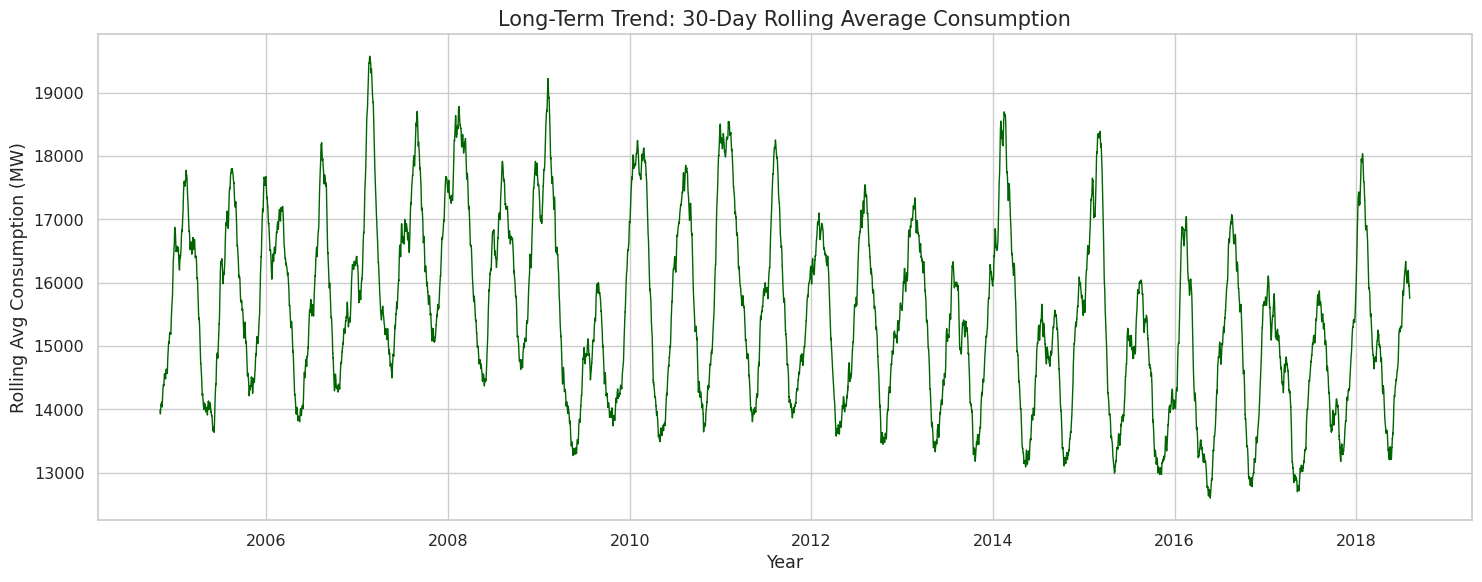

In [24]:
plt.figure(figsize=(15, 6))

rolling_30d = eda_df["AEP_MW"].rolling(24*30).mean()  # ~30-day rolling average

sns.lineplot(x=eda_df.index, y=rolling_30d, color="darkgreen", linewidth=1)

plt.title("Long-Term Trend: 30-Day Rolling Average Consumption", fontsize=15)
plt.xlabel("Year")
plt.ylabel("Rolling Avg Consumption (MW)")
plt.tight_layout()
plt.show()

# **Phase4:Feature Engineering**

In [25]:
# Time-Based Feature Engineering

feature_df = df.copy()

feature_df["Hour"] = feature_df.index.hour
feature_df["Day"] = feature_df.index.day
feature_df["Month"] = feature_df.index.month
feature_df["Year"] = feature_df.index.year
feature_df["DayOfWeek"] = feature_df.index.dayofweek
feature_df["Quarter"] = feature_df.index.quarter

# Weekend Indicator
feature_df["IsWeekend"] = feature_df["DayOfWeek"].isin([5, 6]).astype(int)

# ------------------------------------------------------------------
# Lag & Rolling Features (FIX: this was the missing piece)
# Calendar features alone only encode the "typical" repeating shape
# of demand. They cannot capture how load is actually behaving right
# now (weather, unusual days, trend shifts). Lag/rolling features
# give the model the recent actual consumption history, which is by
# far the strongest predictor of near-future load.
# ------------------------------------------------------------------
feature_df["lag_1"] = feature_df["AEP_MW"].shift(1)          # previous hour
feature_df["lag_24"] = feature_df["AEP_MW"].shift(24)         # same hour, previous day
feature_df["lag_168"] = feature_df["AEP_MW"].shift(168)       # same hour, previous week
feature_df["roll_mean_24"] = feature_df["AEP_MW"].shift(1).rolling(24).mean()  # trailing 24h avg

# Drop the leading rows that don't have full lag history (first 168 hours)
feature_df = feature_df.dropna()

print("Time-based + lag/rolling features created successfully!")
print(f"Rows after dropping NaN lag rows: {feature_df.shape[0]}")

Time-based + lag/rolling features created successfully!
Rows after dropping NaN lag rows: 121101


In [26]:
feature_df.head()

,AEP_MW,Hour,Day,Month,Year,DayOfWeek,Quarter,IsWeekend,lag_1,lag_24,lag_168,roll_mean_24
Datetime,,,,,,,,,,,,
2004-10-08 01:00:00,12468.0,1,8,10,2004,4,4,0,13271.0,12484.0,12379.0,14450.333333
2004-10-08 02:00:00,12046.0,2,8,10,2004,4,4,0,12468.0,12054.0,11935.0,14449.666667
2004-10-08 03:00:00,11749.0,3,8,10,2004,4,4,0,12046.0,11745.0,11692.0,14449.333333
2004-10-08 04:00:00,11784.0,4,8,10,2004,4,4,0,11749.0,11757.0,11597.0,14449.500000
2004-10-08 05:00:00,11919.0,5,8,10,2004,4,4,0,11784.0,12041.0,11681.0,14450.625000


In [27]:
feature_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 121101 entries, 2004-10-08 01:00:00 to 2018-08-03 00:00:00
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   AEP_MW        121101 non-null  float64
 1   Hour          121101 non-null  int32  
 2   Day           121101 non-null  int32  
 3   Month         121101 non-null  int32  
 4   Year          121101 non-null  int32  
 5   DayOfWeek     121101 non-null  int32  
 6   Quarter       121101 non-null  int32  
 7   IsWeekend     121101 non-null  int64  
 8   lag_1         121101 non-null  float64
 9   lag_24        121101 non-null  float64
 10  lag_168       121101 non-null  float64
 11  roll_mean_24  121101 non-null  float64
dtypes: float64(5), int32(6), int64(1)
memory usage: 9.2 MB


In [28]:
feature_df.isnull().sum()

,0
AEP_MW,0
Hour,0
Day,0
Month,0
Year,0
DayOfWeek,0
Quarter,0
IsWeekend,0
lag_1,0
lag_24,0


# **Phase5:Model Training**

# Overview

In this phase, we train multiple machine learning models to forecast hourly electricity consumption.

Since this is a time-series forecasting problem, the dataset is split chronologically to prevent data leakage. The models are trained on historical observations and evaluated on future observations.

### Models

- Linear Regression (Baseline)
- Random Forest Regressor
- XGBoost Regressor

In [29]:
# Select Features and Target Variable

X = feature_df.drop(columns=["AEP_MW"])
y = feature_df["AEP_MW"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (121101, 11)
Target Shape  : (121101,)


In [30]:
# Chronological Train-Test Split

split_index = int(len(feature_df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

Training Samples : 96880
Testing Samples  : 24221


In [31]:
lr = LinearRegression()
lr.fit(X_train, y_train)

print("Linear Regression Trained")

Linear Regression Trained


In [32]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print("Random Forest Trained")

Random Forest Trained


In [33]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=8,
    random_state=42
)
xgb.fit(X_train, y_train)
print("XGBoost Trained")

XGBoost Trained


In [34]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

print("Predictions Generated")

Predictions Generated


# **Phase6:Model Evaluation**

In [35]:
# Import Evaluation Metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
print("Evaluation Metrices imported")

Evaluation Metrices imported


In [36]:
# Model Evaluation Function

def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R² Score": round(r2, 4)
    }

In [37]:
# Evaluate Models

results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        lr_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred
    )
)

In [38]:
# Model Comparison

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R² Score
0,Linear Regression,379.77,482.96,0.9610
1,Random Forest,144.37,196.60,0.9935
2,XGBoost,126.13,170.70,0.9951


In [39]:
# Best Model Selection

best_model = results_df.sort_values(
    by="R² Score",
    ascending=False
).iloc[0]

print("Best Model")
print(best_model)

Best Model
Model       XGBoost
MAE          126.13
RMSE          170.7
R² Score     0.9951
Name: 2, dtype: object


In [40]:
X_test

,Hour,Day,Month,Year,DayOfWeek,Quarter,IsWeekend,lag_1,lag_24,lag_168,roll_mean_24
Datetime,,,,,,,,,,,
2015-10-28 17:00:00,17,28,10,2015,2,4,0,13988.0,14365.0,13762.0,13810.041667
2015-10-28 18:00:00,18,28,10,2015,2,4,0,14069.0,14596.0,13650.0,13797.708333
2015-10-28 19:00:00,19,28,10,2015,2,4,0,13887.0,15098.0,13773.0,13768.166667
2015-10-28 20:00:00,20,28,10,2015,2,4,0,14236.0,15422.0,14372.0,13732.250000
2015-10-28 21:00:00,21,28,10,2015,2,4,0,14565.0,15225.0,14184.0,13696.541667
...,...,...,...,...,...,...,...,...,...,...,...
2018-08-02 20:00:00,20,2,8,2018,3,3,0,18118.0,16579.0,19006.0,15543.958333
2018-08-02 21:00:00,21,2,8,2018,3,3,0,17673.0,16457.0,18322.0,15589.541667
2018-08-02 22:00:00,22,2,8,2018,3,3,0,17303.0,16197.0,17804.0,15624.791667


In [41]:
y_pred = xgb.predict(X_test)

In [42]:
y_pred

array([13876.191, 14069.608, 13992.485, ..., 16907.762, 15832.87 ,
       14556.115], dtype=float32)

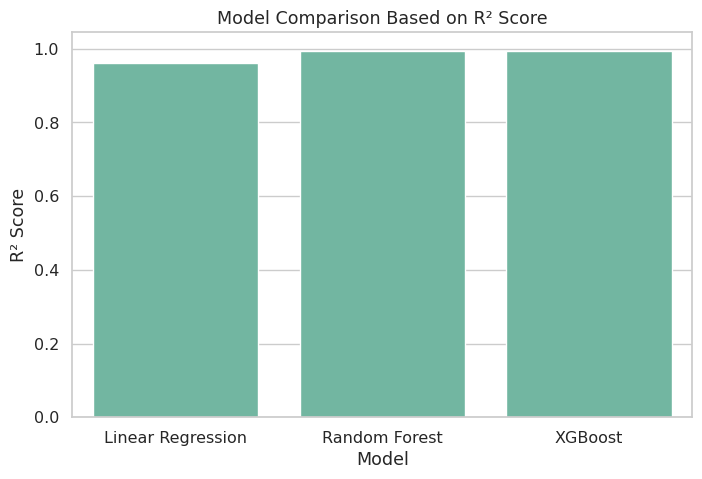

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R² Score"
)

plt.title("Model Comparison Based on R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.show()

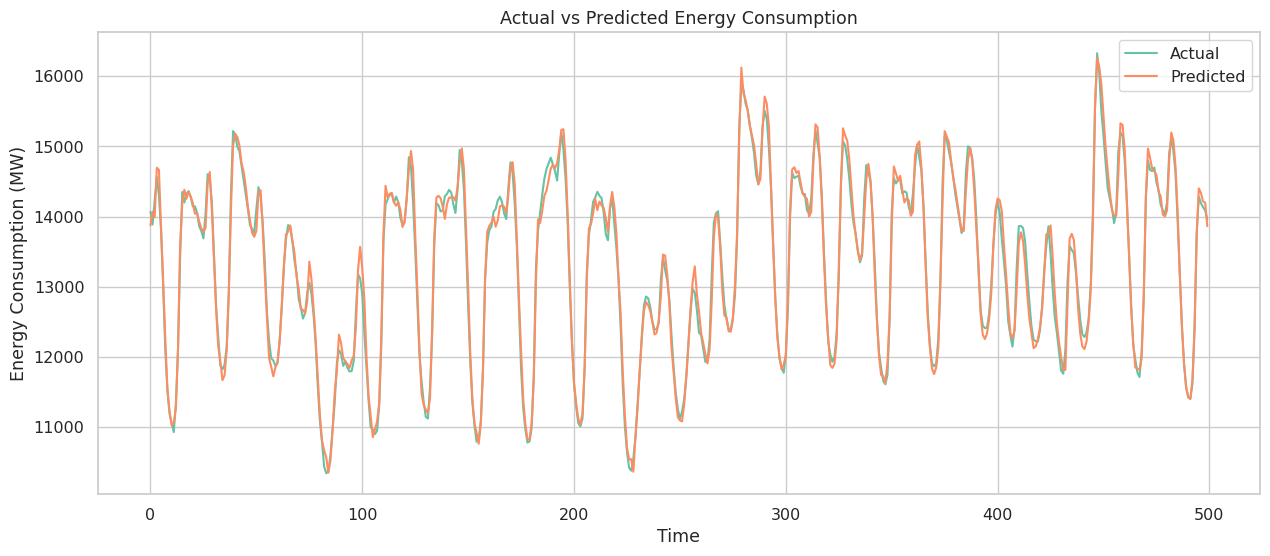

In [44]:
plt.figure(figsize=(15,6))

plt.plot(y_test.values[:500], label="Actual")
plt.plot(y_pred[:500], label="Predicted")

plt.title("Actual vs Predicted Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Energy Consumption (MW)")
plt.legend()

plt.show()

# **Phase7:Feature Importance Analysis**

In [45]:
#Random Forest Feature Importance

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)
rf_importance

,Feature,Importance
7,lag_1,0.952377
0,Hour,0.035499
10,roll_mean_24,0.003150
2,Month,0.002874
8,lag_24,0.001466
4,DayOfWeek,0.001012
5,Quarter,0.000961
9,lag_168,0.000896
1,Day,0.000618
3,Year,0.000578


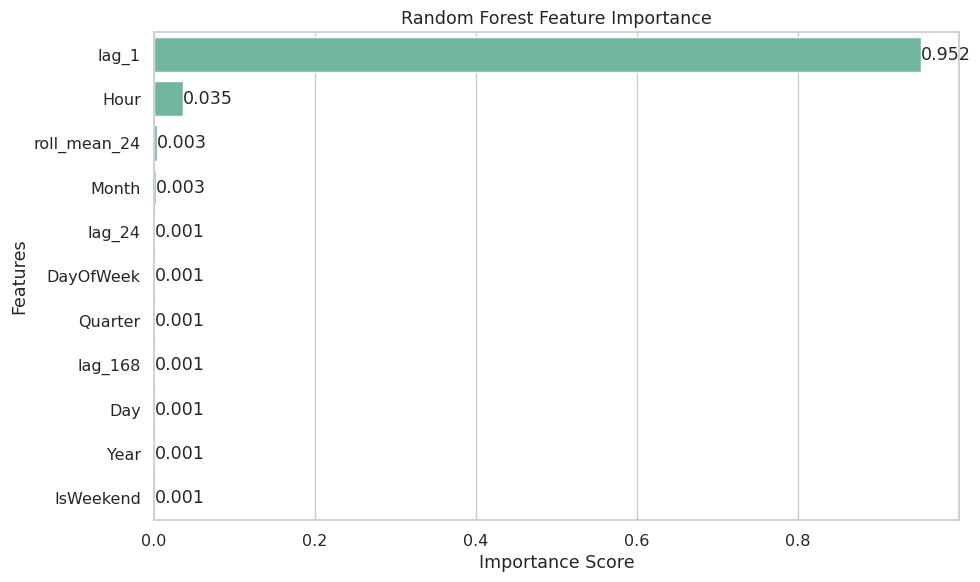

In [46]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [47]:
# XGBoost Feature Importance
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_importance

,Feature,Importance
7,lag_1,0.967997
0,Hour,0.019787
2,Month,0.003853
4,DayOfWeek,0.003380
10,roll_mean_24,0.002092
8,lag_24,0.001417
9,lag_168,0.000636
3,Year,0.000505
1,Day,0.000333
6,IsWeekend,0.000000


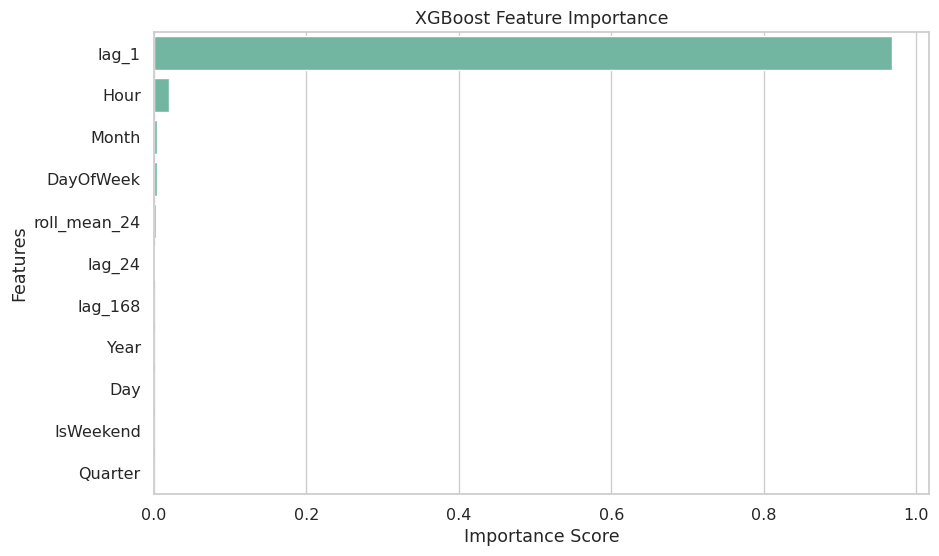

In [48]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=xgb_importance,
    x="Importance",
    y="Feature"
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

XGBoost importance by group:
           Group  Importance
0       Calendar    0.027858
1  Lag / Rolling    0.972142


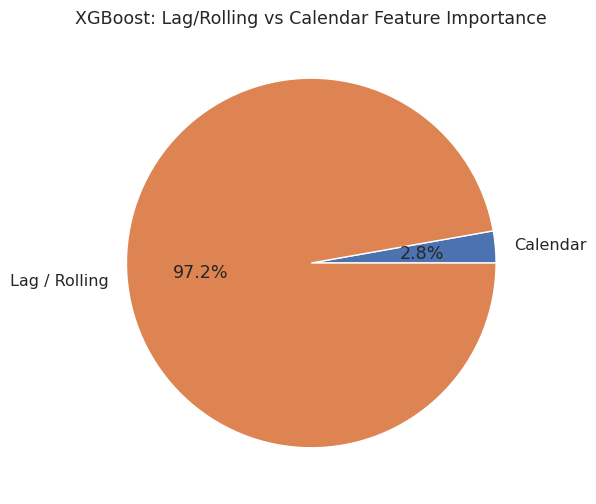

In [49]:
# Grouped Feature Importance: Lag/Rolling vs Calendar Features
# ------------------------------------------------------------
# Instead of comparing 12 individual bars, group features into two
# categories to see, at a glance, how much predictive power comes
# from "recent history" vs "calendar position".

lag_features = ["lag_1", "lag_24", "lag_168", "roll_mean_24"]
calendar_features = ["Hour", "Day", "Month", "Year", "DayOfWeek", "Quarter", "IsWeekend"]

def grouped_importance(importance_df):
    grouped = importance_df.copy()
    grouped["Group"] = grouped["Feature"].apply(
        lambda f: "Lag / Rolling" if f in lag_features else "Calendar"
    )
    return grouped.groupby("Group")["Importance"].sum().reset_index()

xgb_grouped = grouped_importance(xgb_importance)
print("XGBoost importance by group:")
print(xgb_grouped)

plt.figure(figsize=(6,6))
plt.pie(
    xgb_grouped["Importance"],
    labels=xgb_grouped["Group"],
    autopct="%1.1f%%",
    colors=["#4C72B0", "#DD8452"]
)
plt.title("XGBoost: Lag/Rolling vs Calendar Feature Importance")
plt.show()

XGBoost WITHOUT lag_1:
MAE  : 516.51
RMSE : 679.45
R2   : 0.9228


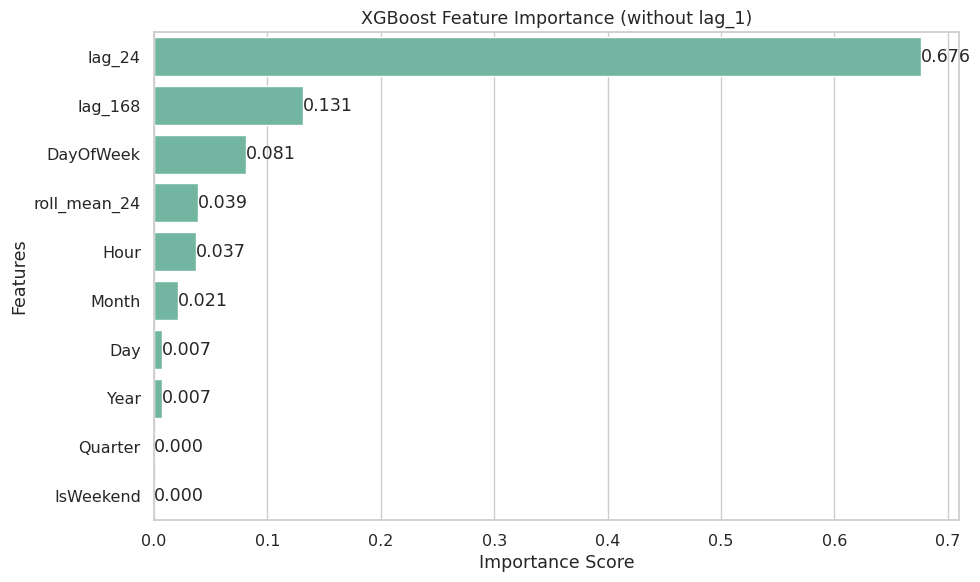

In [50]:
# Refit XGBoost without lag_1 to see importance of remaining features
X_train_no_lag1 = X_train.drop(columns=["lag_1"])
X_test_no_lag1 = X_test.drop(columns=["lag_1"])

xgb_no_lag1 = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=8,
    random_state=42
)
xgb_no_lag1.fit(X_train_no_lag1, y_train)
pred_no_lag1 = xgb_no_lag1.predict(X_test_no_lag1)

print("XGBoost WITHOUT lag_1:")
print("MAE  :", round(mean_absolute_error(y_test, pred_no_lag1), 2))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, pred_no_lag1)), 2))
print("R2   :", round(r2_score(y_test, pred_no_lag1), 4))

xgb_no_lag1_importance = pd.DataFrame({
    "Feature": X_train_no_lag1.columns,
    "Importance": xgb_no_lag1.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
ax2 = sns.barplot(data=xgb_no_lag1_importance, x="Importance", y="Feature")
for container in ax2.containers:
    ax2.bar_label(container, fmt="%.3f")
plt.title("XGBoost Feature Importance (without lag_1)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

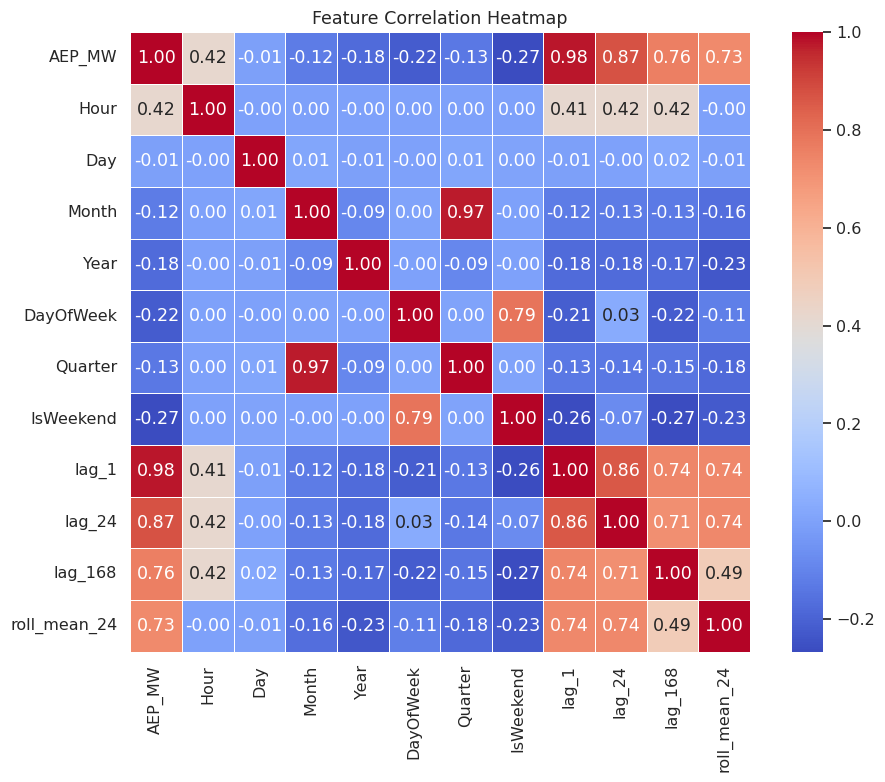

In [51]:
# Feature Correlation Heatmap

plt.figure(figsize=(10, 8))

correlation_matrix = feature_df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

# **Phase 8: Save Best Model**

In [52]:
import joblib

# Save trained model
joblib.dump(xgb, "PJM_ENERGY_CONSUMPTION.joblib")

print("✅ Model saved successfully!")

✅ Model saved successfully!
